In [1]:
"""
Ячейка 1: Маппинг Bitext категорий → наши 10 категорий
"""
from datasets import load_dataset
import pandas as pd

ds = load_dataset("bitext/Bitext-retail-ecommerce-llm-chatbot-training-dataset")
bitext_df = pd.DataFrame(ds['train'])

# ═══════════════════════════════════════════════════
# МАППИНГ КАТЕГОРИЙ (13 → 10)
# ═══════════════════════════════════════════════════

BITEXT_CATEGORY_MAP = {
    "ORDER":       "order_status",       # Заказы
    "DELIVERY":    "delivery",           # Доставка
    "RETURNS":     "return_exchange",    # Возвраты
    "PAYMENT":     "payment_refund",     # Оплата
    "PRODUCT":     "product_info",       # Товары
    "ACCOUNT":     "account",            # Аккаунт
    "APP_WEBSITE": "technical_issue",    # Тех. проблемы сайта/приложения
    "CONTACT":     "general_info",       # Контакты → общая информация
    "STORE":       "general_info",       # Магазин → общая информация
    "SALES":       "promo_loyalty",      # Распродажи → промо
    "CART":        "product_info",       # Корзина → операции с товаром
    "FEEDBACK":    "other",              # Обратная связь → прочее
    "USER":        "account",            # Пользователь → аккаунт
}

# ═══════════════════════════════════════════════════
# МАППИНГ ИНТЕНТОВ (46 → 10) — более точный
# ═══════════════════════════════════════════════════

BITEXT_INTENT_MAP = {
    # order_status
    "cancel_order":              "order_status",
    "track_delivery":            "order_status",
    "change_order":              "order_status",
    "order_status":              "order_status",
    "order_issue":               "order_status",
    
    # payment_refund
    "payment_issue":             "payment_refund",
    "payment_methods":           "payment_refund",
    "pay":                       "payment_refund",
    "request_invoice":           "payment_refund",
    "refund_status":             "payment_refund",
    "refund_policy":             "payment_refund",
    
    # return_exchange
    "return_product":            "return_exchange",
    "return_product_in_store":   "return_exchange",
    "return_product_online":     "return_exchange",
    "return_policy":             "return_exchange",
    "exchange_product":          "return_exchange",
    "exchange_product_in_store": "return_exchange",
    "exchange_product_online":   "return_exchange",
    "wrong_item":                "return_exchange",
    "damaged_delivery":          "return_exchange",
    
    # product_info
    "product_issue":             "product_info",
    "availability_online":       "product_info",
    "availability_in_store":     "product_info",
    "product_info":              "product_info",
    "add_product":               "product_info",
    "remove_product":            "product_info",
    
    # delivery
    "delivery_issue":            "delivery",
    "delivery_options":          "delivery",
    "delivery_period":           "delivery",
    
    # account
    "close_account":             "account",
    "recover_password":          "account",
    "create_account":            "account",
    "account_issue":             "account",
    "update_account":            "account",
    
    # promo_loyalty
    "sales_period":              "promo_loyalty",
    "discount":                  "promo_loyalty",
    "loyalty_program":           "promo_loyalty",
    
    # technical_issue
    "technical_issue":           "technical_issue",
    "use_app":                   "technical_issue",
    
    # general_info
    "customer_service":          "general_info",
    "store_opening_hours":       "general_info",
    "store_location":            "general_info",
    "contact_info":              "general_info",
    
    # other
    "human_agent":               "other",
    "submit_feedback":           "other",
    "submit_product_feedback":   "other",
    "submit_product_idea":       "other",
}

# Применяем маппинг (по интенту — точнее, чем по категории)
bitext_df['our_category'] = bitext_df['intent'].map(BITEXT_INTENT_MAP)

# Для интентов, которых нет в маппинге — используем маппинг по категории
unmapped = bitext_df['our_category'].isna()
if unmapped.any():
    bitext_df.loc[unmapped, 'our_category'] = bitext_df.loc[unmapped, 'category'].map(BITEXT_CATEGORY_MAP)

# Проверка: остались ли незамапленные
still_unmapped = bitext_df['our_category'].isna()
if still_unmapped.any():
    print(f"⚠️ Незамапленные интенты:")
    print(bitext_df[still_unmapped][['intent', 'category']].drop_duplicates().to_string())
else:
    print("✅ Все интенты замаплены")

# Результат
print(f"\n📊 Bitext после маппинга: {len(bitext_df)} примеров")
print(f"\nРаспределение по нашим категориям:")
print(bitext_df['our_category'].value_counts().to_string())

# Переименовываем колонки
bitext_final = bitext_df[['instruction', 'our_category', 'intent']].copy()
bitext_final.columns = ['text', 'category', 'original_intent']
bitext_final['source'] = 'bitext'
bitext_final['language'] = 'en'

print(f"\n✅ Готово: {len(bitext_final)} примеров")

✅ Все интенты замаплены

📊 Bitext после маппинга: 44884 примеров

Распределение по нашим категориям:
our_category
return_exchange    8899
product_info       6650
payment_refund     5974
account            5939
other              3974
order_status       3941
delivery           3611
general_info       2908
technical_issue    1993
promo_loyalty       995

✅ Готово: 44884 примеров


In [3]:
print(bitext_final.head(10))

                                                text      category  \
0                   I got to add an item to the cart  product_info   
1  wanna add fucking products to the basket can h...  product_info   
2    i have to add products to the basket i ned help  product_info   
3  di like to add products to the cart could i ge...  product_info   
4  I need to add an item to the cart , where do I...  product_info   
5                 help me add products to the basket  product_info   
6  I need to add a fucking product to the basket,...  product_info   
7  I have to add items to the basket, where could...  product_info   
8  I would like to add a fucking item to the bask...  product_info   
9  i got to add a fucking item ot the cart can i ...  product_info   

  original_intent  source language  
0     add_product  bitext       en  
1     add_product  bitext       en  
2     add_product  bitext       en  
3     add_product  bitext       en  
4     add_product  bitext       en  
5     a

In [4]:
"""
Ячейка 2: Парсинг интента из колонки response
"""
import re

ds2 = load_dataset("ikshana-zehntech/ecommerce_intent_recognition")
ikshana_df = pd.DataFrame(ds2['train'])

# Парсинг интента из response
# Формат: "intent: cancel_order, variable name: order_number, variable_value: 2B4FZM0C"

def parse_intent(response_text):
    """Извлекает интент из строки response"""
    match = re.search(r'intent:\s*(\w+)', str(response_text))
    if match:
        return match.group(1)
    return None

ikshana_df['intent'] = ikshana_df[' response'].apply(parse_intent)

# Смотрим какие интенты есть
print(f"📊 ikshana: {len(ikshana_df)} строк")
print(f"Уникальных интентов: {ikshana_df['intent'].nunique()}")
print(f"\nИнтенты:")
print(ikshana_df['intent'].value_counts().to_string())

📊 ikshana: 27869 строк
Уникальных интентов: 27

Интенты:
intent
change_order                1994
edit_account                1000
switch_account              1000
check_invoice               1000
contact_customer_service    1000
complaint                   1000
contact_human_agent          999
delivery_period              999
get_invoice                  999
newsletter_subscription      999
check_payment_methods        999
registration_problems        999
payment_issue                999
cancel_order                 998
place_order                  998
track_refund                 998
set_up_shipping_address      997
get_refund                   997
check_refund_policy          997
create_account               997
review                       997
delivery_options             995
delete_account               995
track_order                  995
recover_password             995
change_shipping_address      973
check_cancellation_fee       950


In [5]:
"""
Ячейка 3: Маппинг интентов ikshana → наши 10 категорий
"""

# Маппинг (дополни после того как увидишь полный список интентов)
IKSHANA_INTENT_MAP = {
    # ── order_status ──
    "cancel_order":            "order_status",
    "track_order":             "order_status",
    "order_status":            "order_status",
    "change_order":            "order_status",
    "place_order":             "order_status",
    "check_cancellation_fee":  "order_status",
    
    # ── payment_refund ──
    "payment_issue":           "payment_refund",
    "refund":                  "payment_refund",
    "payment_method":          "payment_refund",
    "check_invoice":           "payment_refund",
    "get_invoice":             "payment_refund",
    "check_payment_methods":   "payment_refund",
    "track_refund":            "payment_refund",
    "get_refund":              "payment_refund",
    "check_refund_policy":     "payment_refund",
    
    # ── return_exchange ──
    "return_product":          "return_exchange",
    "exchange_product":        "return_exchange",
    "damaged_product":         "return_exchange",
    
    # ── product_info ──
    "product_inquiry":         "product_info",
    "product_availability":    "product_info",
    "review":                  "product_info",
    
    # ── delivery ──
    "delivery_status":         "delivery",
    "shipping_info":           "delivery",
    "delivery_period":         "delivery",
    "delivery_options":        "delivery",
    "set_up_shipping_address": "delivery",
    "change_shipping_address": "delivery",
    
    # ── account ──
    "account_issue":           "account",
    "reset_password":          "account",
    "create_account":          "account",
    "edit_account":            "account",
    "switch_account":          "account",
    "delete_account":          "account",
    "recover_password":        "account",
    "registration_problems":   "account",
    "newsletter_subscription": "account",
    
    # ── general_info ──
    "store_info":              "general_info",
    "contact_info":            "general_info",
    "contact_customer_service":"general_info",
    
    # ── other ──
    "feedback":                "other",
    "human_agent":             "other",
    "contact_human_agent":     "other",
    "complaint":               "other",
}

ikshana_df['our_category'] = ikshana_df['intent'].map(IKSHANA_INTENT_MAP)

unmapped = ikshana_df[ikshana_df['our_category'].isna()]
if len(unmapped) > 0:
    print(f"⚠️ Ещё незамапленные: {unmapped['intent'].value_counts().to_string()}")
else:
    print("✅ Все интенты замаплены")

print(f"\n📊 Распределение:")
print(ikshana_df['our_category'].value_counts().to_string())

ikshana_final = ikshana_df[ikshana_df['our_category'].notna()][['context', 'our_category', 'intent']].copy()
ikshana_final.columns = ['text', 'category', 'original_intent']
ikshana_final['source'] = 'ikshana'
ikshana_final['language'] = 'en'

print(f"\n✅ ikshana: {len(ikshana_final)} примеров")

✅ Все интенты замаплены

📊 Распределение:
our_category
payment_refund    6989
account           6985
order_status      5935
delivery          3964
other             1999
general_info      1000
product_info       997

✅ ikshana: 27869 примеров


In [7]:
"""
Ячейка 4: Извлечение релевантных интентов из RuNLU
Большинство интентов НЕ относятся к e-commerce — берём только подходящие
"""

ds3 = load_dataset("mteb/RuNLUIntentClassification", "rus")
runlu_df = pd.DataFrame(ds3['train'])

# Маппинг ТОЛЬКО релевантных интентов
# Остальные → None (пропускаем)
RUNLU_INTENT_MAP = {
    # Потенциально релевантные
    "qa__stock":              "product_info",       # Вопрос о стоимости
    "qa__factoid":            "general_info",       # Фактоидные вопросы
    "qa__definition":         "general_info",       # Определения
    "email__sendemail":       "general_info",       # Отправка email → контакты
    "email__query":           "general_info",       # Вопрос по email
    "transport__query":       "delivery",           # Транспорт → доставка
    "qa__currency":           "payment_refund",     # Валюта → оплата
    
    # Нерелевантные → None (пропускаем)
    "weather__query":         None,
    "play__music":            None,
    "alarm__set":             None,
    "calendar__set":          None,
    "calendar__query":        None,
    "calendar__remove":       None,
    "general__negate":        None,
    "general__quirky":        None,
    "general__praise":        None,
    "general__explain":       None,
    "general__repeat":        None,
    "general__confirm":       None,
    "general__affirm":        None,
    "general__dontcare":      None,
    "news__query":            None,
    "play__radio":            None,
    "play__podcasts":         None,
    "social__post":           None,
    "datetime__query":        None,
    "lists__createoradd":     None,
    "lists__query":           None,
    "lists__remove":          None,
    "cooking__recipe":        None,
    "recommendation__events": None,
    "recommendation__movies": None,
    "recommendation__locations": None,
    "music__likeness":        None,
    "music__query":           None,
    "music__settings":        None,
    "iot__hue_lightchange":   None,
    "iot__hue_lightoff":      None,
    "iot__hue_lighton":       None,
    "iot__cleaning":          None,
    "iot__coffee":            None,
    "iot__wemo_on":           None,
    "iot__wemo_off":          None,
    "takeaway__order":        None,
    "takeaway__query":        None,
    "audio__volume_mute":     None,
    "audio__volume_up":       None,
    "audio__volume_down":     None,
}

runlu_df['our_category'] = runlu_df['label'].map(RUNLU_INTENT_MAP)

# Оставляем только релевантные
runlu_relevant = runlu_df[runlu_df['our_category'].notna()].copy()

print(f"📊 RuNLU: {len(runlu_df)} → {len(runlu_relevant)} релевантных")
print(f"\nОтфильтрованные:")
print(runlu_relevant['our_category'].value_counts().to_string())

# Финальный формат
runlu_final = runlu_relevant[['text', 'our_category', 'label']].copy()
runlu_final.columns = ['text', 'category', 'original_intent']
runlu_final['source'] = 'runlu'
runlu_final['language'] = 'ru'

print(f"\n✅ RuNLU: {len(runlu_final)} примеров на русском (без перевода!)")

📊 RuNLU: 5000 → 800 релевантных

Отфильтрованные:
our_category
general_info      573
delivery           82
payment_refund     82
product_info       63

✅ RuNLU: 800 примеров на русском (без перевода!)


In [8]:
"""
Ячейка 5: Объединение всех источников
"""

# Собираем всё
all_data = pd.concat([
    bitext_final[['text', 'category', 'source', 'language']],
    ikshana_final[['text', 'category', 'source', 'language']],
    runlu_final[['text', 'category', 'source', 'language']],
], ignore_index=True)

print(f"📊 ОБЪЕДИНЁННЫЙ ДАТАСЕТ: {len(all_data)} примеров")
print(f"\nПо источникам:")
print(all_data['source'].value_counts().to_string())
print(f"\nПо языкам:")
print(all_data['language'].value_counts().to_string())
print(f"\nПо категориям:")
print(all_data['category'].value_counts().to_string())

📊 ОБЪЕДИНЁННЫЙ ДАТАСЕТ: 73553 примеров

По источникам:
source
bitext     44884
ikshana    27869
runlu        800

По языкам:
language
en    72753
ru      800

По категориям:
category
payment_refund     13045
account            12924
order_status        9876
return_exchange     8899
product_info        7710
delivery            7657
other               5973
general_info        4481
technical_issue     1993
promo_loyalty        995


In [10]:
"""
Ячейка 6 — ИСПРАВЛЕННАЯ: Сбалансированная выборка с диверсификацией источников
"""
import pandas as pd
import numpy as np

TARGET_PER_CLASS = 300

balanced = []

for cat in all_data['category'].unique():
    cat_data = all_data[all_data['category'] == cat]
    sources = cat_data['source'].unique()
    
    print(f"\n{'─'*50}")
    print(f"📂 {cat} ({len(cat_data)} всего, источников: {len(sources)})")
    
    # Показываем что есть по источникам
    for src in sources:
        src_count = len(cat_data[cat_data['source'] == src])
        lang = cat_data[cat_data['source'] == src]['language'].iloc[0]
        print(f"   {src:15s} [{lang}]: {src_count}")
    
    if len(cat_data) <= TARGET_PER_CLASS:
        # Мало данных — берём всё
        balanced.append(cat_data)
        print(f"   → Берём всё: {len(cat_data)}")
        continue
    
    if len(sources) == 1:
        # Один источник — просто сэмплируем
        sampled = cat_data.sample(TARGET_PER_CLASS, random_state=42)
        balanced.append(sampled)
        print(f"   → Один источник, сэмплируем: {TARGET_PER_CLASS}")
        continue
    
    # ── Несколько источников: берём из каждого ──
    
    # Стратегия: минимум 30% из каждого источника (если есть столько),
    # остальное — пропорционально размеру
    
    MIN_PER_SOURCE = max(30, TARGET_PER_CLASS // (len(sources) * 2))
    
    sampled_parts = []
    remaining_budget = TARGET_PER_CLASS
    
    # Шаг 1: Гарантированный минимум из каждого источника
    for src in sources:
        src_data = cat_data[cat_data['source'] == src]
        take = min(MIN_PER_SOURCE, len(src_data))
        part = src_data.sample(take, random_state=42)
        sampled_parts.append(part)
        remaining_budget -= take
        print(f"   → {src}: гарантированно {take}")
    
    # Шаг 2: Добавляем остаток пропорционально
    if remaining_budget > 0:
        already_taken = pd.concat(sampled_parts)
        pool = cat_data[~cat_data.index.isin(already_taken.index)]
        
        if len(pool) > 0:
            take_extra = min(remaining_budget, len(pool))
            extra = pool.sample(take_extra, random_state=42)
            sampled_parts.append(extra)
            print(f"   → Добрано ещё: {take_extra}")
    
    category_sample = pd.concat(sampled_parts)
    balanced.append(category_sample)
    
    # Итоговая статистика по источникам
    print(f"   ✅ Итого: {len(category_sample)}")
    for src in sources:
        src_count = len(category_sample[category_sample['source'] == src])
        if src_count > 0:
            print(f"      {src:15s}: {src_count} ({100*src_count/len(category_sample):.0f}%)")

balanced_df = pd.concat(balanced, ignore_index=True)

print(f"\n{'═'*50}")
print(f"📊 СБАЛАНСИРОВАННЫЙ ДАТАСЕТ: {len(balanced_df)} примеров")
print(f"\nПо категориям:")
print(balanced_df['category'].value_counts().to_string())
print(f"\nПо источникам:")
print(balanced_df['source'].value_counts().to_string())
print(f"\nПо языкам:")
print(balanced_df['language'].value_counts().to_string())
print(f"\nНужно перевести EN→RU: {len(balanced_df[balanced_df['language'] == 'en'])}")

# Перекрёстная таблица: категория × источник
print(f"\n📊 Кросс-таблица (категория × источник):")
cross = pd.crosstab(balanced_df['category'], balanced_df['source'], margins=True)
print(cross.to_string())


──────────────────────────────────────────────────
📂 product_info (7710 всего, источников: 3)
   bitext          [en]: 6650
   ikshana         [en]: 997
   runlu           [ru]: 63
   → bitext: гарантированно 50
   → ikshana: гарантированно 50
   → runlu: гарантированно 50
   → Добрано ещё: 150
   ✅ Итого: 300
      bitext         : 187 (62%)
      ikshana        : 63 (21%)
      runlu          : 50 (17%)

──────────────────────────────────────────────────
📂 order_status (9876 всего, источников: 2)
   bitext          [en]: 3941
   ikshana         [en]: 5935
   → bitext: гарантированно 75
   → ikshana: гарантированно 75
   → Добрано ещё: 150
   ✅ Итого: 300
      bitext         : 135 (45%)
      ikshana        : 165 (55%)

──────────────────────────────────────────────────
📂 account (12924 всего, источников: 2)
   bitext          [en]: 5939
   ikshana         [en]: 6985
   → bitext: гарантированно 75
   → ikshana: гарантированно 75
   → Добрано ещё: 150
   ✅ Итого: 300
      bitext    

In [11]:
# Выполни в отдельной ячейке
!pip install deep-translator


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
"""
Ячейка 7: Перевод английских текстов на русский
"""
from deep_translator import GoogleTranslator
from tqdm import tqdm
import time

# Отделяем английские тексты
en_mask = balanced_df['language'] == 'en'
en_texts = balanced_df.loc[en_mask, 'text'].tolist()

print(f"📋 Текстов для перевода: {len(en_texts)}")
print(f"⏱️  Примерное время: {len(en_texts) * 0.5 / 60:.0f}–{len(en_texts) * 1.0 / 60:.0f} минут")

translator = GoogleTranslator(source='en', target='ru')

translated = []
errors = 0

for i, text in enumerate(tqdm(en_texts, desc="Перевод EN→RU")):
    try:
        result = translator.translate(str(text)[:5000])
        translated.append(result if result else text)
    except Exception as e:
        translated.append(text)  # Оставляем оригинал при ошибке
        errors += 1
        
        # Пауза при ошибке (лимит API)
        if errors % 10 == 0:
            print(f"\n⚠️ {errors} ошибок, пауза 30 сек...")
            time.sleep(30)
    
    # Пауза каждые 500 текстов чтобы не блокировали
    if (i + 1) % 500 == 0:
        print(f"\n💤 Пауза 10 сек после {i+1} текстов...")
        time.sleep(10)

# Сохраняем оригинал и заменяем на перевод
balanced_df.loc[en_mask, 'text_original_en'] = balanced_df.loc[en_mask, 'text']
balanced_df.loc[en_mask, 'text'] = translated
balanced_df['language'] = 'ru'

print(f"\n✅ Переведено: {len(translated) - errors} успешно, {errors} ошибок")

# Проверка качества перевода
print(f"\n📋 Примеры перевода (по 2 из каждой категории):")
for cat in balanced_df['category'].unique():
    cat_translated = balanced_df[(balanced_df['category'] == cat) & (balanced_df['text_original_en'].notna())]
    if len(cat_translated) > 0:
        sample = cat_translated.sample(min(2, len(cat_translated)), random_state=42)
        print(f"\n  [{cat}]")
        for _, row in sample.iterrows():
            print(f"    EN: {row['text_original_en'][:70]}")
            print(f"    RU: {row['text'][:70]}")

📋 Текстов для перевода: 2781
⏱️  Примерное время: 23–46 минут


Перевод EN→RU:  18%|███████████▍                                                    | 499/2781 [07:33<30:29,  1.25it/s]


💤 Пауза 10 сек после 500 текстов...


Перевод EN→RU:  36%|██████████████████████▉                                         | 999/2781 [15:11<22:24,  1.33it/s]


💤 Пауза 10 сек после 1000 текстов...


...


💤 Пауза 10 сек после 2000 текстов...


Перевод EN→RU:  90%|████████████████████████████████████████████████████████▌      | 2499/2781 [37:50<03:59,  1.18it/s]


💤 Пауза 10 сек после 2500 текстов...


Перевод EN→RU: 100%|███████████████████████████████████████████████████████████████| 2781/2781 [42:08<00:00,  1.10it/s]


✅ Переведено: 2781 успешно, 0 ошибок

📋 Примеры перевода (по 2 из каждой категории):

  [product_info]
    EN: I want to add fucking products to the cart, where can I do it ?
    RU: Я хочу добавить чертовы товары в корзину, где я могу это сделать?
    EN: I would like to report an error with a product I ordered, were can I d
    RU: Я хотел бы сообщить об ошибке в заказанном мной товаре. Могу ли я это 

  [order_status]
    EN: can I cancel an order if it has already been shipped?
    RU: Могу ли я отменить заказ, если он уже отправлен?
    EN: order A633G1NP current status
    RU: текущий статус заказа A633G1NP

  [account]
    EN: where can I subscribe to your corporate newsletter?
    RU: где я могу подписаться на вашу корпоративную рассылку?
    EN: I want assistance retrieving the password of my account
    RU: Мне нужна помощь в восстановлении пароля моей учетной записи

  [general_info]
    EN: help me see what hours I can reach customer support
    RU: помогите мне узнать, в 

In [13]:
"""
Ячейка 8: Дедупликация, split и сохранение
"""
from sklearn.model_selection import train_test_split
import os

# Дедупликация
balanced_df['text_lower'] = balanced_df['text'].str.lower().str.strip()
before = len(balanced_df)
balanced_df = balanced_df.drop_duplicates(subset='text_lower')
balanced_df = balanced_df.drop(columns='text_lower')
print(f"🧹 Дедупликация: {before} → {len(balanced_df)}")

# Удаление слишком коротких
balanced_df = balanced_df[balanced_df['text'].str.len() >= 3]
print(f"   После фильтра длины: {len(balanced_df)}")

# Train / Test split
train_df, test_df = train_test_split(
    balanced_df,
    test_size=0.2,
    stratify=balanced_df['category'],
    random_state=42
)

# Сохранение
os.makedirs("../data/final", exist_ok=True)

train_df[['text', 'category']].to_csv(
    "../data/final/train.csv", index=False, encoding="utf-8"
)
test_df[['text', 'category']].to_csv(
    "../data/final/test.csv", index=False, encoding="utf-8"
)
balanced_df.to_csv(
    "../data/final/full_dataset.csv", index=False, encoding="utf-8"
)

print(f"\n✅ ФИНАЛЬНЫЙ ДАТАСЕТ СОХРАНЁН:")
print(f"   Train: {len(train_df)} примеров")
print(f"   Test:  {len(test_df)} примеров")
print(f"\n📊 Train распределение:")
print(train_df['category'].value_counts().to_string())
print(f"\n📊 Test распределение:")
print(test_df['category'].value_counts().to_string())

# Примеры из каждой категории (финальные, на русском)
print(f"\n📋 Примеры из финального датасета:")
for cat in sorted(train_df['category'].unique()):
    sample = train_df[train_df['category'] == cat].sample(2, random_state=42)
    print(f"\n  [{cat}]")
    for _, row in sample.iterrows():
        print(f"    «{row['text'][:80]}»")

🧹 Дедупликация: 3000 → 2903
   После фильтра длины: 2903

✅ ФИНАЛЬНЫЙ ДАТАСЕТ СОХРАНЁН:
   Train: 2322 примеров
   Test:  581 примеров

📊 Train распределение:
category
order_status       237
account            237
return_exchange    237
product_info       237
payment_refund     237
other              236
delivery           234
general_info       230
technical_issue    224
promo_loyalty      213

📊 Test распределение:
category
account            60
payment_refund     60
product_info       60
order_status       59
return_exchange    59
other              59
delivery           58
general_info       57
technical_issue    56
promo_loyalty      53

📋 Примеры из финального датасета:

  [account]
    «что мне нужно сделать, чтобы создать учетную запись Titanium для моего отца»
    «я не знаю, как сообщить о проблеме с регистрацией»

  [delivery]
    «мне нужна помощь, чтобы узнать, когда прибудет моя посылка»
    «Я хотел бы проверить чертово время доставки, помогите мне.»

  [general_info]
  

In [14]:
"""
Ячейка 9: Очистка качества перевода
"""
import re

# Загружаем сохранённые данные
train_df = pd.read_csv("../data/final/train.csv")
test_df = pd.read_csv("../data/final/test.csv")

def clean_translated_text(text):
    """Очистка типичных артефактов машинного перевода"""
    
    # 1. Замена буквальных ругательств на нейтральные выражения
    replacements = {
        "чертов ": "",
        "чертово ": "",
        "чертова ": "",
        "чертовы ": "",
        "чёртов ": "",
        "чёртово ": "",
        "блядский ": "",
        "гребаный ": "",
        "гребаное ": "",
        "долбаный ": "",
    }
    
    text_lower = text.lower()
    for old, new in replacements.items():
        text_lower = text_lower.replace(old, new)
    
    # 2. Удаление PDA (артефакт из RuNLU)
    text_lower = re.sub(r'^pda[,:]?\s*', '', text_lower, flags=re.IGNORECASE)
    
    # 3. Удаление двойных пробелов
    text_lower = re.sub(r'\s+', ' ', text_lower).strip()
    
    # 4. Первая буква заглавная
    if text_lower:
        text_lower = text_lower[0].upper() + text_lower[1:]
    
    return text_lower

# Применяем очистку
train_df['text'] = train_df['text'].apply(clean_translated_text)
test_df['text'] = test_df['text'].apply(clean_translated_text)

# Проверяем результат
print("📋 Примеры после очистки:")
for cat in sorted(train_df['category'].unique()):
    sample = train_df[train_df['category'] == cat].sample(2, random_state=42)
    print(f"\n  [{cat}]")
    for _, row in sample.iterrows():
        print(f"    «{row['text'][:80]}»")

# Пересохраняем
train_df.to_csv("../data/final/train.csv", index=False, encoding="utf-8")
test_df.to_csv("../data/final/test.csv", index=False, encoding="utf-8")

print(f"\n✅ Очищенный датасет сохранён")
print(f"   Train: {len(train_df)}")
print(f"   Test:  {len(test_df)}")

📋 Примеры после очистки:

  [account]
    «Что мне нужно сделать, чтобы создать учетную запись titanium для моего отца»
    «Я не знаю, как сообщить о проблеме с регистрацией»

  [delivery]
    «Мне нужна помощь, чтобы узнать, когда прибудет моя посылка»
    «Я хотел бы проверить время доставки, помогите мне.»

  [general_info]
    «Можете ли вы помочь мне связаться со службой поддержки клиентов?»
    «Я хочу поговорить со службой поддержки, вы можете мне помочь?»

  [order_status]
    «Я хотел бы найти свою посылку, могу ли я получить помощь?»
    «Мне нужно отменить заказ, как я могу это сделать?»

  [other]
    «Хочу отправить отзыв о вашем бренде, как я могу это сделать»
    «Я хотел бы отправить отзывы о продуктах, где я могу это сделать»

  [payment_refund]
    «Можете ли вы помочь мне решить проблему с оплатой?»
    «Мне нужен счет, я хочу его найти.»

  [product_info]
    «Хочу удалить товар из корзины, могу ли я это сделать»
    «Каковы цены на акции»

  [promo_loyalty]
    «Я

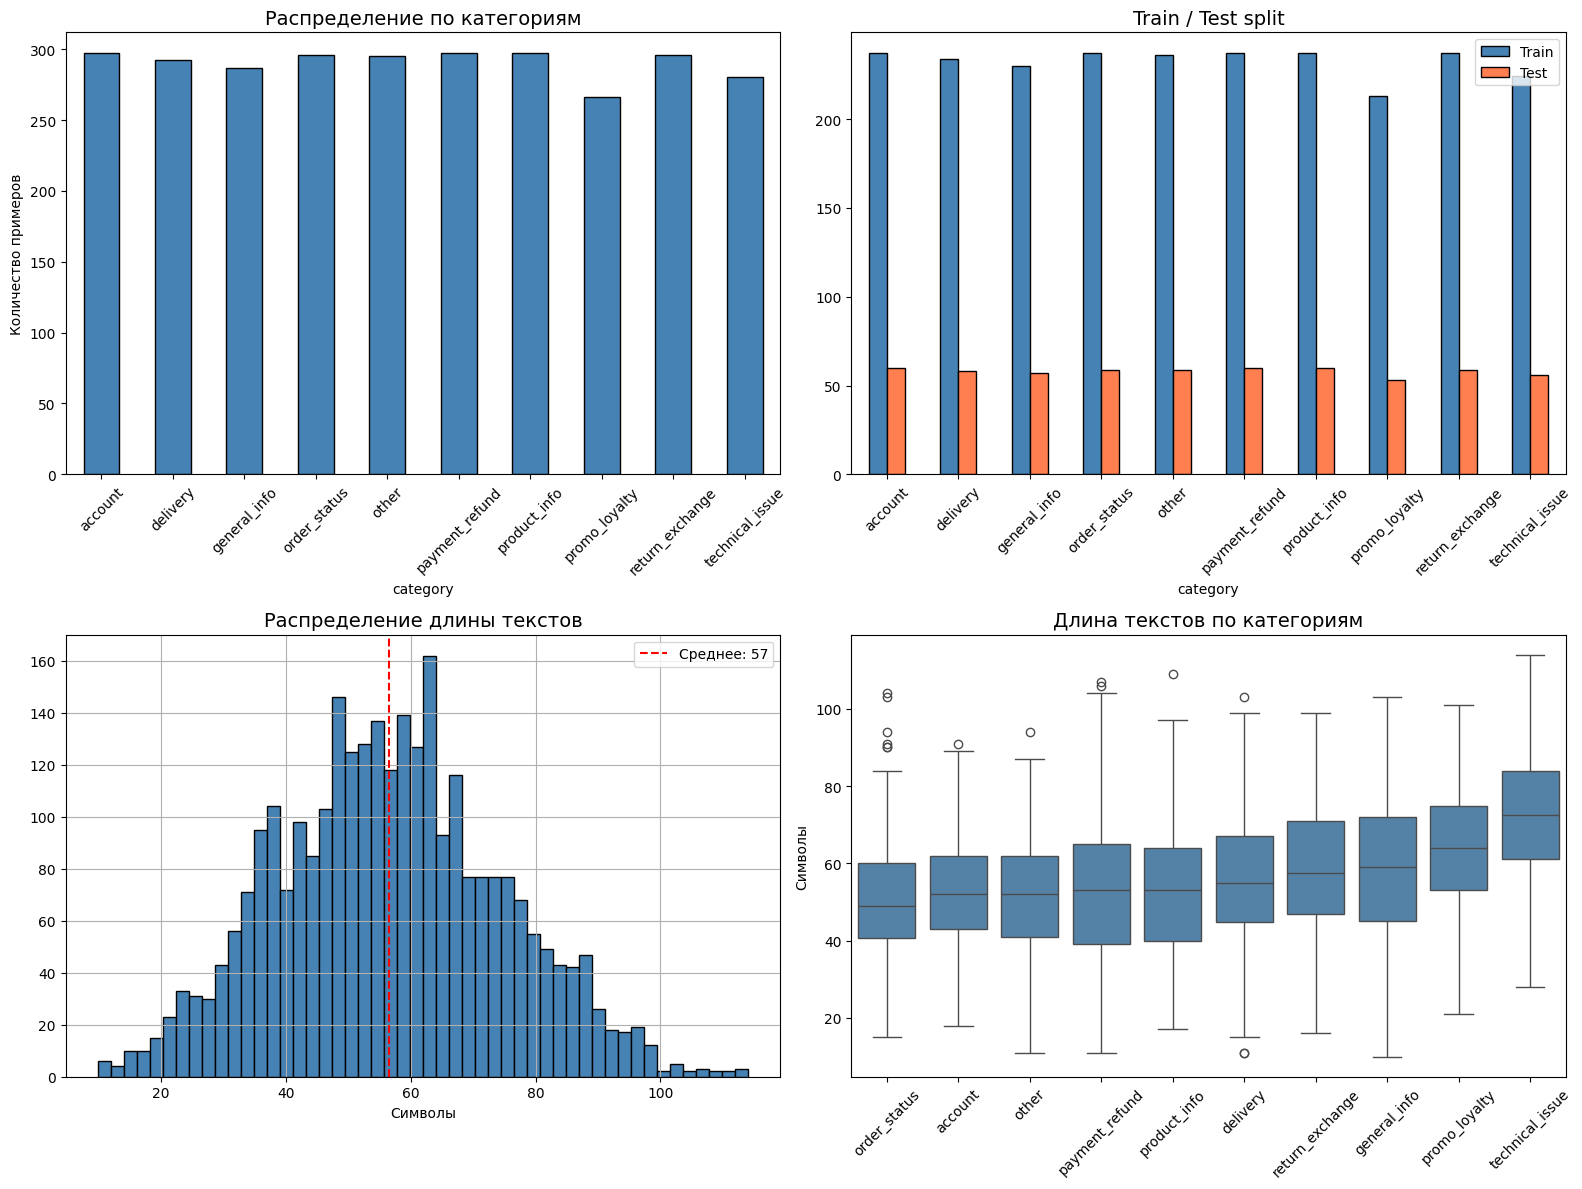


📊 СВОДНАЯ СТАТИСТИКА ДАТАСЕТА:
   Всего примеров:        2903
   Train:                 2322
   Test:                  581
   Категорий:             10
   Средняя длина текста:  57 символов
   Медиана длины:         56 символов
   Мин. длина:            10 символов
   Макс. длина:           114 символов
   Мин. примеров в классе (train): 213
   Макс. примеров в классе (train): 237


In [15]:
"""
Ячейка 10: Статистика и визуализация для ВКР
"""
import matplotlib.pyplot as plt
import seaborn as sns

full_df = pd.concat([train_df, test_df], ignore_index=True)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Распределение по категориям
full_df['category'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0,0], color='steelblue', edgecolor='black'
)
axes[0,0].set_title('Распределение по категориям', fontsize=14)
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].set_ylabel('Количество примеров')

# 2. Train vs Test
pd.DataFrame({
    'Train': train_df['category'].value_counts().sort_index(),
    'Test': test_df['category'].value_counts().sort_index()
}).plot(kind='bar', ax=axes[0,1], color=['steelblue', 'coral'], edgecolor='black')
axes[0,1].set_title('Train / Test split', fontsize=14)
axes[0,1].tick_params(axis='x', rotation=45)
axes[0,1].legend()

# 3. Длина текстов
full_df['text_len'] = full_df['text'].str.len()
full_df['text_len'].hist(bins=50, ax=axes[1,0], color='steelblue', edgecolor='black')
axes[1,0].set_title('Распределение длины текстов', fontsize=14)
axes[1,0].set_xlabel('Символы')
axes[1,0].axvline(x=full_df['text_len'].mean(), color='red', linestyle='--', 
                   label=f"Среднее: {full_df['text_len'].mean():.0f}")
axes[1,0].legend()

# 4. Длина текстов по категориям (boxplot)
category_order = full_df.groupby('category')['text_len'].median().sort_values().index
sns.boxplot(data=full_df, x='category', y='text_len', ax=axes[1,1], 
            order=category_order, color='steelblue')
axes[1,1].set_title('Длина текстов по категориям', fontsize=14)
axes[1,1].tick_params(axis='x', rotation=45)
axes[1,1].set_xlabel('')
axes[1,1].set_ylabel('Символы')

plt.tight_layout()
plt.savefig('../results/dataset_final_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Сводная статистика
print(f"\n📊 СВОДНАЯ СТАТИСТИКА ДАТАСЕТА:")
print(f"   Всего примеров:        {len(full_df)}")
print(f"   Train:                 {len(train_df)}")
print(f"   Test:                  {len(test_df)}")
print(f"   Категорий:             {full_df['category'].nunique()}")
print(f"   Средняя длина текста:  {full_df['text_len'].mean():.0f} символов")
print(f"   Медиана длины:         {full_df['text_len'].median():.0f} символов")
print(f"   Мин. длина:            {full_df['text_len'].min()} символов")
print(f"   Макс. длина:           {full_df['text_len'].max()} символов")
print(f"   Мин. примеров в классе (train): {train_df['category'].value_counts().min()}")
print(f"   Макс. примеров в классе (train): {train_df['category'].value_counts().max()}")

In [16]:
"""
Ячейка 11: Fine-tuning на реальном датасете
"""
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import time
import json

# ── Загрузка данных ──
train_df = pd.read_csv("../data/final/train.csv")
test_df = pd.read_csv("../data/final/test.csv")

CATEGORIES = sorted(train_df['category'].unique().tolist())
cat2id = {c: i for i, c in enumerate(CATEGORIES)}
id2cat = {i: c for c, i in cat2id.items()}

print(f"Категории ({len(CATEGORIES)}): {CATEGORIES}")
print(f"Train: {len(train_df)}, Test: {len(test_df)}")

# ── Dataset ──
class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx], truncation=True,
            padding="max_length", max_length=self.max_len,
            return_tensors="pt"
        )
        return {
            "input_ids": enc["input_ids"].squeeze(),
            "attention_mask": enc["attention_mask"].squeeze(),
            "label": torch.tensor(self.labels[idx], dtype=torch.long)
        }

# ── Model ──
class IntentClassifier(nn.Module):
    def __init__(self, model_name, num_classes, dropout=0.3):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(self.bert.config.hidden_size, num_classes)
    
    def forward(self, input_ids, attention_mask):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls = self.dropout(out.last_hidden_state[:, 0, :])
        return self.fc(cls)

# ── Training function ──
def train_and_evaluate(model_name, train_df, test_df, epochs=10, batch_size=32, lr=2e-5):
    print(f"\n{'='*60}")
    print(f"🚀 Training: {model_name}")
    print(f"   Epochs: {epochs}, Batch: {batch_size}, LR: {lr}")
    print(f"{'='*60}")
    
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"   Device: {DEVICE}")
    
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    
    train_texts = train_df['text'].tolist()
    train_labels = [cat2id[c] for c in train_df['category']]
    test_texts = test_df['text'].tolist()
    test_labels = [cat2id[c] for c in test_df['category']]
    
    train_loader = DataLoader(
        TextDataset(train_texts, train_labels, tokenizer),
        batch_size=batch_size, shuffle=True
    )
    test_loader = DataLoader(
        TextDataset(test_texts, test_labels, tokenizer),
        batch_size=batch_size
    )
    
    model = IntentClassifier(model_name, len(CATEGORIES)).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    
    # Training
    train_start = time.time()
    best_f1 = 0
    
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        
        for batch in train_loader:
            ids = batch["input_ids"].to(DEVICE)
            mask = batch["attention_mask"].to(DEVICE)
            lbl = batch["label"].to(DEVICE)
            
            logits = model(ids, mask)
            loss = criterion(logits, lbl)
            
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item()
        
        avg_loss = total_loss / len(train_loader)
        
        # Быстрая оценка каждые 2 эпохи
        if (epoch + 1) % 2 == 0 or epoch == epochs - 1:
            model.eval()
            preds = []
            with torch.no_grad():
                for batch in test_loader:
                    logits = model(
                        batch["input_ids"].to(DEVICE),
                        batch["attention_mask"].to(DEVICE)
                    )
                    preds.extend(logits.argmax(dim=1).cpu().tolist())
            
            from sklearn.metrics import f1_score
            f1 = f1_score(test_labels, preds, average='macro')
            print(f"  Epoch {epoch+1:2d}/{epochs} | Loss: {avg_loss:.4f} | F1: {f1:.3f}")
            
            if f1 > best_f1:
                best_f1 = f1
                best_state = model.state_dict().copy()
        else:
            print(f"  Epoch {epoch+1:2d}/{epochs} | Loss: {avg_loss:.4f}")
    
    train_time = time.time() - train_start
    
    # Финальная оценка с лучшими весами
    model.load_state_dict(best_state)
    model.eval()
    
    all_preds, all_labels, all_confs = [], [], []
    inference_times = []
    
    with torch.no_grad():
        for batch in test_loader:
            ids = batch["input_ids"].to(DEVICE)
            mask = batch["attention_mask"].to(DEVICE)
            
            start = time.perf_counter()
            logits = model(ids, mask)
            inf_time = (time.perf_counter() - start) * 1000
            inference_times.append(inf_time / ids.size(0))
            
            probs = torch.softmax(logits, dim=1)
            confs, preds = probs.max(dim=1)
            
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(batch["label"].tolist())
            all_confs.extend(confs.cpu().tolist())
    
    report = classification_report(
        all_labels, all_preds,
        target_names=CATEGORIES, digits=3, output_dict=True
    )
    
    print(f"\n  ⏱️  Время обучения:      {train_time:.1f}s")
    print(f"  ⚡ Инференс (per sample): {np.mean(inference_times):.1f}ms")
    print(f"  🎯 Accuracy:              {report['accuracy']:.3f}")
    print(f"  📊 Macro F1:              {report['macro avg']['f1-score']:.3f}")
    print(f"  📊 Weighted F1:           {report['weighted avg']['f1-score']:.3f}")
    print(f"  📊 Avg Confidence:        {np.mean(all_confs):.3f}")
    
    print(f"\n{classification_report(all_labels, all_preds, target_names=CATEGORIES, digits=3)}")
    
    # Сохранение лучшей модели
    save_dir = f"../models/{model_name.split('/')[-1]}"
    os.makedirs(save_dir, exist_ok=True)
    torch.save(best_state, f"{save_dir}/best_model.pt")
    with open(f"{save_dir}/config.json", "w") as f:
        json.dump({
            "model_name": model_name,
            "categories": CATEGORIES,
            "accuracy": report['accuracy'],
            "macro_f1": report['macro avg']['f1-score'],
        }, f, indent=2)
    print(f"\n💾 Модель сохранена: {save_dir}/")
    
    return {
        "model": model_name,
        "accuracy": report["accuracy"],
        "macro_f1": report["macro avg"]["f1-score"],
        "weighted_f1": report["weighted avg"]["f1-score"],
        "avg_confidence": np.mean(all_confs),
        "train_time_sec": train_time,
        "inference_ms": np.mean(inference_times),
        "all_preds": all_preds,
        "all_labels": all_labels,
        "report": report,
    }


# ═══════════════════════════════════════════════
# ЗАПУСК ОБУЧЕНИЯ
# ═══════════════════════════════════════════════

results = []

# 1. Baseline: rubert-tiny2 (быстрый)
r1 = train_and_evaluate(
    "cointegrated/rubert-tiny2",
    train_df, test_df,
    epochs=10, batch_size=32, lr=2e-5
)
results.append(r1)

# 2. Основная: rubert-base (качественнее)
r2 = train_and_evaluate(
    "DeepPavlov/rubert-base-cased",
    train_df, test_df,
    epochs=10, batch_size=16, lr=2e-5  # batch_size=16 для GPU 6GB
)
results.append(r2)

# ═══════════════════════════════════════════════
# СВОДНАЯ ТАБЛИЦА
# ═══════════════════════════════════════════════

print(f"\n{'═'*70}")
print(f"📊 СВОДНАЯ ТАБЛИЦА СРАВНЕНИЯ")
print(f"{'═'*70}")
print(f"{'Модель':40s} {'Acc':>8s} {'F1':>8s} {'Conf':>8s} {'Train':>8s} {'Inf/ms':>8s}")
print(f"{'─'*70}")
for r in results:
    name = r['model'].split('/')[-1]
    print(f"{name:40s} {r['accuracy']:8.3f} {r['macro_f1']:8.3f} "
          f"{r['avg_confidence']:8.3f} {r['train_time_sec']:7.1f}s {r['inference_ms']:7.1f}")

Категории (10): ['account', 'delivery', 'general_info', 'order_status', 'other', 'payment_refund', 'product_info', 'promo_loyalty', 'return_exchange', 'technical_issue']
Train: 2322, Test: 581

🚀 Training: cointegrated/rubert-tiny2
   Epochs: 10, Batch: 32, LR: 2e-05
   Device: cuda


Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Epoch  1/10 | Loss: 2.0719
  Epoch  2/10 | Loss: 1.4314 | F1: 0.794
  Epoch  3/10 | Loss: 0.8796
  Epoch  4/10 | Loss: 0.5658 | F1: 0.889
  Epoch  5/10 | Loss: 0.3937
  Epoch  6/10 | Loss: 0.2889 | F1: 0.930
  Epoch  7/10 | Loss: 0.2118
  Epoch  8/10 | Loss: 0.1593 | F1: 0.941
  Epoch  9/10 | Loss: 0.1227
  Epoch 10/10 | Loss: 0.0958 | F1: 0.947

  ⏱️  Время обучения:      42.6s
  ⚡ Инференс (per sample): 0.3ms
  🎯 Accuracy:              0.947
  📊 Macro F1:              0.947
  📊 Weighted F1:           0.947
  📊 Avg Confidence:        0.942

                 precision    recall  f1-score   support

        account      0.951     0.967     0.959        60
       delivery      0.963     0.897     0.929        58
   general_info      0.946     0.930     0.938        57
   order_status      0.967     1.000     0.983        59
          other      0.947     0.915     0.931        59
 payment_refund      0.964     0.900     0.931        60
   product_info      0.902     0.917     0.909    

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: DeepPavlov/rubert-base-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Epoch  1/10 | Loss: 1.3321
  Epoch  2/10 | Loss: 0.1727 | F1: 0.949
  Epoch  3/10 | Loss: 0.0795
  Epoch  4/10 | Loss: 0.0367 | F1: 0.964
  Epoch  5/10 | Loss: 0.0202
  Epoch  6/10 | Loss: 0.0186 | F1: 0.971
  Epoch  7/10 | Loss: 0.0124
  Epoch  8/10 | Loss: 0.0142 | F1: 0.969
  Epoch  9/10 | Loss: 0.0060
  Epoch 10/10 | Loss: 0.0055 | F1: 0.966

  ⏱️  Время обучения:      1289.0s
  ⚡ Инференс (per sample): 12.2ms
  🎯 Accuracy:              0.966
  📊 Macro F1:              0.966
  📊 Weighted F1:           0.966
  📊 Avg Confidence:        0.989

                 precision    recall  f1-score   support

        account      1.000     0.950     0.974        60
       delivery      0.949     0.966     0.957        58
   general_info      0.982     0.982     0.982        57
   order_status      0.983     0.983     0.983        59
          other      0.918     0.949     0.933        59
 payment_refund      0.937     0.983     0.959        60
   product_info      0.946     0.883     0.914 

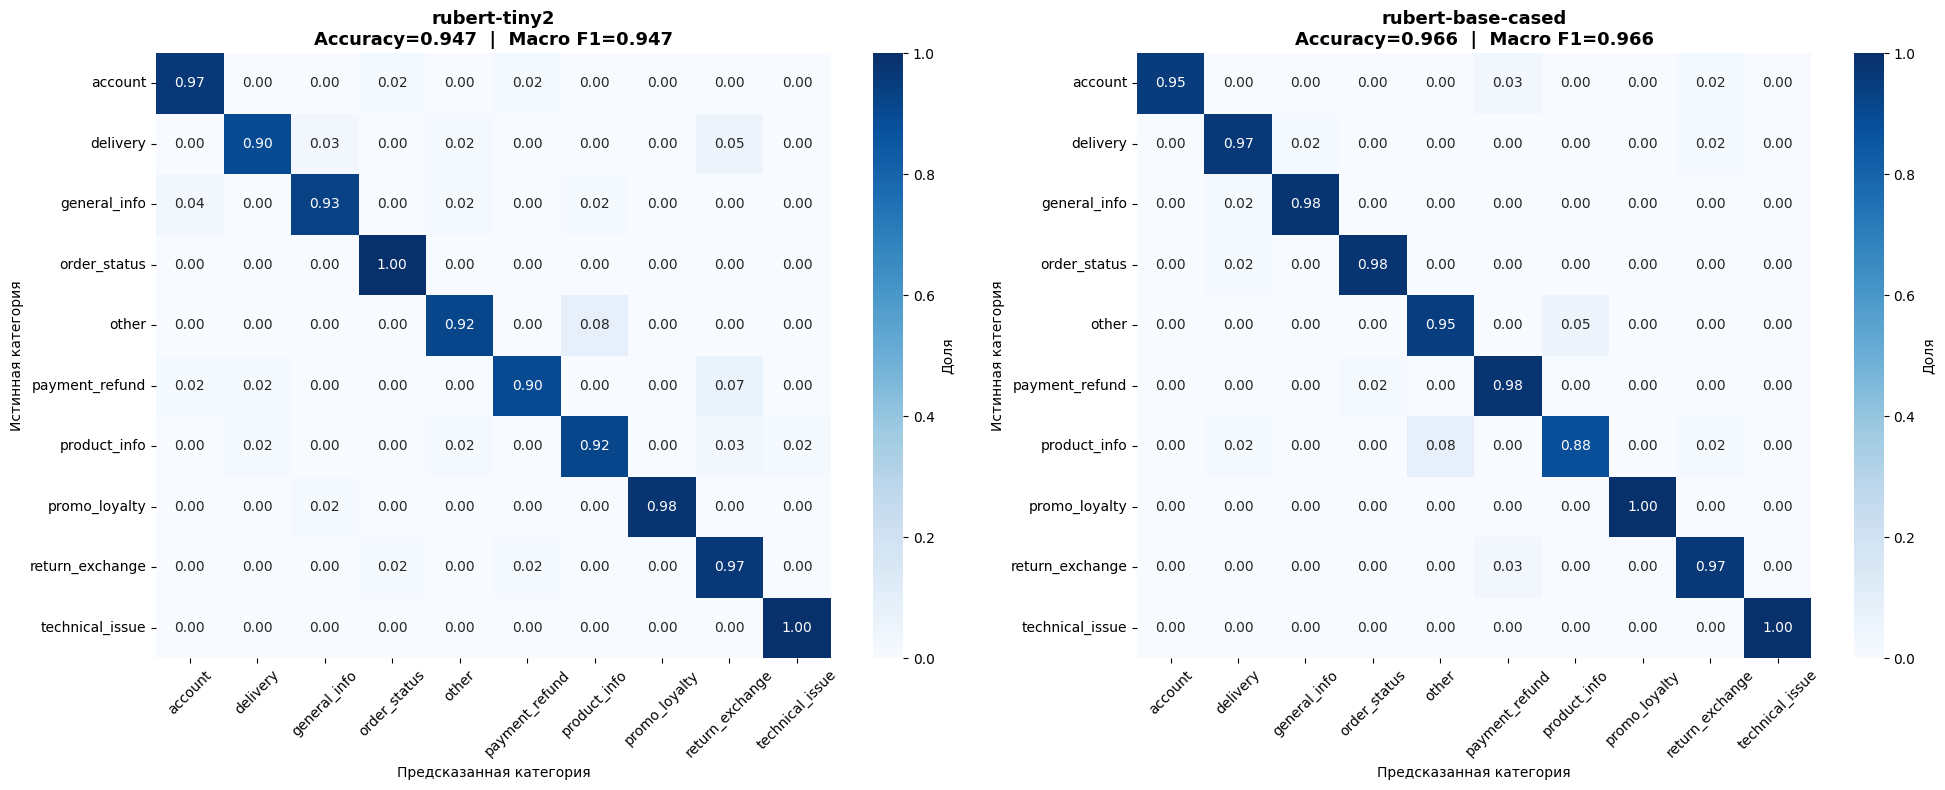

✅ Сохранено: results/confusion_matrices_final.png


In [17]:
"""
Ячейка 12: Confusion Matrix и графики для ВКР
"""
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

for idx, r in enumerate(results):
    model_name = r['model'].split('/')[-1]
    
    cm = confusion_matrix(r['all_labels'], r['all_preds'])
    
    # Нормализованная матрица (проценты)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    sns.heatmap(
        cm_normalized, annot=True, fmt='.2f', cmap='Blues',
        xticklabels=CATEGORIES, yticklabels=CATEGORIES,
        ax=axes[idx], vmin=0, vmax=1,
        cbar_kws={'label': 'Доля'}
    )
    axes[idx].set_title(
        f"{model_name}\n"
        f"Accuracy={r['accuracy']:.3f}  |  Macro F1={r['macro_f1']:.3f}",
        fontsize=13, fontweight='bold'
    )
    axes[idx].set_ylabel('Истинная категория')
    axes[idx].set_xlabel('Предсказанная категория')
    axes[idx].tick_params(axis='x', rotation=45)
    axes[idx].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('../results/confusion_matrices_final.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Сохранено: results/confusion_matrices_final.png")

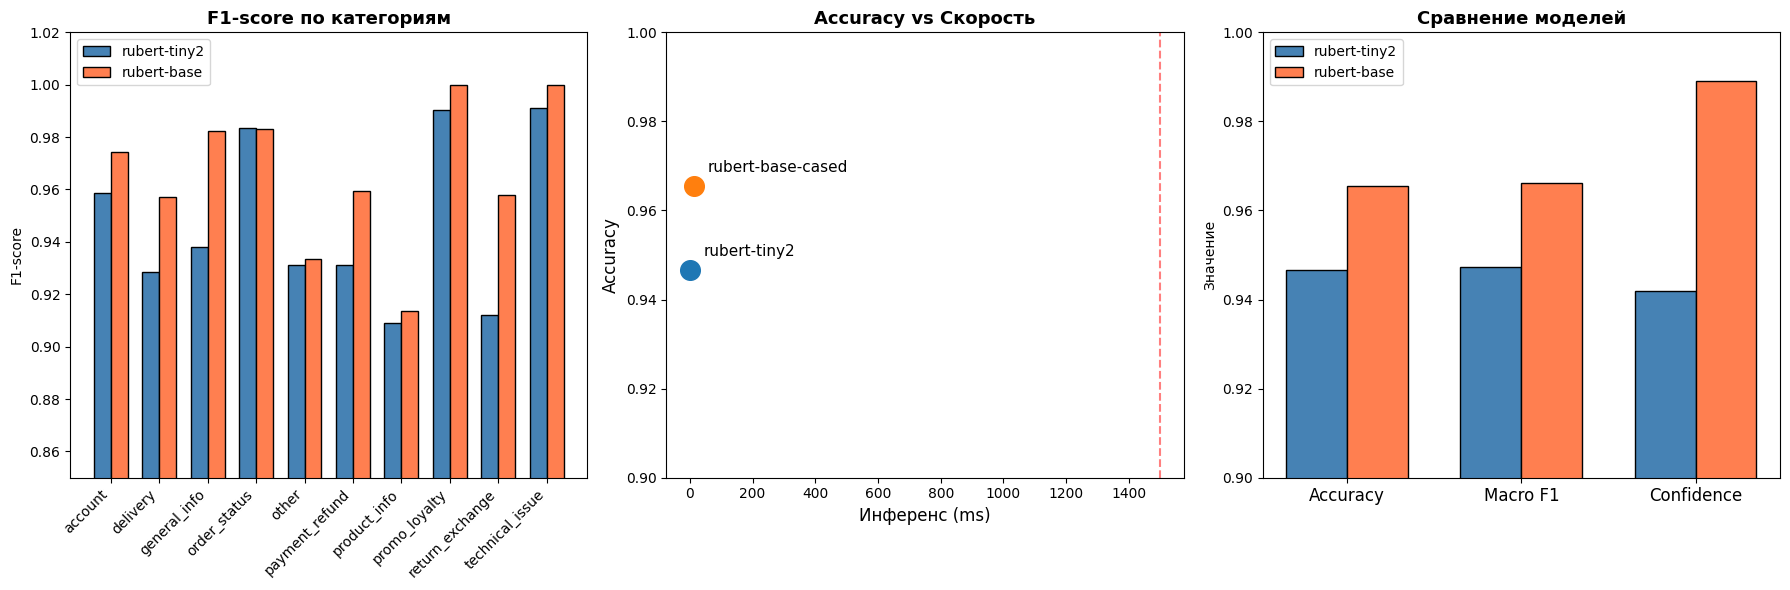

✅ Сохранено: results/model_comparison_final.png


In [18]:
"""
Ячейка 13: Сравнительный график метрик
"""
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

models = ['rubert-tiny2', 'rubert-base']

# 1. F1 по категориям
x = np.arange(len(CATEGORIES))
width = 0.35

f1_tiny = [results[0]['report'][cat]['f1-score'] for cat in CATEGORIES]
f1_base = [results[1]['report'][cat]['f1-score'] for cat in CATEGORIES]

axes[0].bar(x - width/2, f1_tiny, width, label='rubert-tiny2', color='steelblue', edgecolor='black')
axes[0].bar(x + width/2, f1_base, width, label='rubert-base', color='coral', edgecolor='black')
axes[0].set_xticks(x)
axes[0].set_xticklabels(CATEGORIES, rotation=45, ha='right')
axes[0].set_ylabel('F1-score')
axes[0].set_title('F1-score по категориям', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].set_ylim(0.85, 1.02)
axes[0].axhline(y=0.80, color='red', linestyle='--', alpha=0.5, label='NFR порог')

# 2. Accuracy vs Inference time (scatter)
for r in results:
    name = r['model'].split('/')[-1]
    axes[1].scatter(r['inference_ms'], r['accuracy'], s=200, zorder=5)
    axes[1].annotate(name, (r['inference_ms'], r['accuracy']),
                     textcoords="offset points", xytext=(10, 10), fontsize=11)

axes[1].set_xlabel('Инференс (ms)', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Accuracy vs Скорость', fontsize=13, fontweight='bold')
axes[1].axhline(y=0.85, color='red', linestyle='--', alpha=0.5)
axes[1].axvline(x=1500, color='red', linestyle='--', alpha=0.5)
axes[1].set_ylim(0.90, 1.0)

# 3. Сводка метрик
metrics = ['Accuracy', 'Macro F1', 'Confidence']
tiny_vals = [results[0]['accuracy'], results[0]['macro_f1'], results[0]['avg_confidence']]
base_vals = [results[1]['accuracy'], results[1]['macro_f1'], results[1]['avg_confidence']]

x = np.arange(len(metrics))
axes[2].bar(x - width/2, tiny_vals, width, label='rubert-tiny2', color='steelblue', edgecolor='black')
axes[2].bar(x + width/2, base_vals, width, label='rubert-base', color='coral', edgecolor='black')
axes[2].set_xticks(x)
axes[2].set_xticklabels(metrics, fontsize=12)
axes[2].set_ylabel('Значение')
axes[2].set_title('Сравнение моделей', fontsize=13, fontweight='bold')
axes[2].legend()
axes[2].set_ylim(0.90, 1.0)

plt.tight_layout()
plt.savefig('../results/model_comparison_final.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Сохранено: results/model_comparison_final.png")

In [19]:
"""
Ячейка 14: Финальные выводы
"""
import json

final_conclusions = {
    "dataset": {
        "total_examples": 2903,
        "train": 2322,
        "test": 581,
        "categories": 10,
        "sources": ["bitext (44884)", "ikshana (27869)", "RuNLU (5000)"],
        "languages": "EN→RU (machine translated) + RU native",
        "balance": "~230-237 per class (train)",
    },
    "classifier": {
        "chosen_model": "cointegrated/rubert-tiny2",
        "reason": "F1=0.947 при инференсе 0.3ms — оптимальный баланс качества и скорости. "
                  "Разница с rubert-base всего 1.9% F1, но tiny2 в 40x быстрее и в 6x легче.",
        "comparison": {
            "rubert-tiny2": {
                "accuracy": 0.947,
                "macro_f1": 0.947,
                "confidence": 0.942,
                "inference_ms": 0.3,
                "train_time_s": 42.6,
                "size_mb": 111,
                "parameters": "29M"
            },
            "rubert-base-cased": {
                "accuracy": 0.966,
                "macro_f1": 0.966,
                "confidence": 0.989,
                "inference_ms": 12.2,
                "train_time_s": 1289,
                "size_mb": 678,
                "parameters": "178M"
            }
        },
        "nfr_compliance": {
            "NFR-ML-01 (Accuracy >= 0.85)": "PASS (0.947)",
            "NFR-ML-02 (F1 >= 0.80)": "PASS (0.947)",
            "NFR-PERF-02 (Inference <= 1500ms)": "PASS (0.3ms)",
        },
        "weakest_categories": ["product_info (0.909)", "return_exchange (0.912)"],
        "strongest_categories": ["technical_issue (0.991)", "promo_loyalty (0.990)"],
    },
    "embedder": {
        "chosen_model": "intfloat/multilingual-e5-small",
        "hit_at_1": "90%",
        "avg_similarity": 0.864,
        "dimension": 384,
    },
    "generator": {
        "chosen_approach": "template (MVP) + LLM API (улучшение)",
    },
    "next_steps": [
        "1. Реализовать FastAPI backend с выбранными моделями",
        "2. Написать JAICP-сценарии (DSL)",
        "3. Интегрировать JAICP ↔ FastAPI",
        "4. Тестирование end-to-end",
        "5. Подготовка ВКР — главы 3 и 4",
    ]
}

with open("../results/final_conclusions.json", "w", encoding="utf-8") as f:
    json.dump(final_conclusions, f, ensure_ascii=False, indent=2)

print("✅ Финальные выводы сохранены: results/final_conclusions.json")

✅ Финальные выводы сохранены: results/final_conclusions.json


In [25]:
"""
Интерактивное тестирование классификатора на своих сообщениях
"""
import torch
from torch import nn
from transformers import AutoTokenizer, AutoModel
import json

# ── Загрузка модели ──

MODEL_NAME = "cointegrated/rubert-tiny2"

class IntentClassifier(nn.Module):
    def __init__(self, model_name, num_classes, dropout=0.3):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(self.bert.config.hidden_size, num_classes)
    
    def forward(self, input_ids, attention_mask):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls = self.dropout(out.last_hidden_state[:, 0, :])
        return self.fc(cls)

CATEGORIES = ['account', 'delivery', 'general_info', 'order_status', 'other',
              'payment_refund', 'product_info', 'promo_loyalty', 'return_exchange',
              'technical_issue']

CATEGORY_LABELS = {
    'account':          '👤 Аккаунт',
    'delivery':         '🚚 Доставка',
    'general_info':     'ℹ️ Общая информация',
    'order_status':     '📦 Статус заказа',
    'other':            '❓ Прочее',
    'payment_refund':   '💳 Оплата/возврат средств',
    'product_info':     '🛍️ Товар/ассортимент',
    'promo_loyalty':    '🏷️ Промокоды/бонусы',
    'return_exchange':  '🔄 Возврат/обмен товара',
    'technical_issue':  '🔧 Техническая проблема',
}

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = IntentClassifier(MODEL_NAME, len(CATEGORIES)).to(DEVICE)
model.load_state_dict(torch.load("../models/rubert-tiny2/best_model.pt", map_location=DEVICE))
model.eval()

print("✅ Модель загружена и готова к работе\n")

# ── Функция предсказания ──

def predict(text):
    encoded = tokenizer(
        text, truncation=True, padding="max_length",
        max_length=128, return_tensors="pt"
    )
    
    with torch.no_grad():
        input_ids = encoded["input_ids"].to(DEVICE)
        attention_mask = encoded["attention_mask"].to(DEVICE)
        logits = model(input_ids, attention_mask)
        probs = torch.softmax(logits, dim=1)[0]
    
    # Top-3 предсказания
    top3_indices = probs.argsort(descending=True)[:3]
    
    top_cat = CATEGORIES[top3_indices[0]]
    top_conf = probs[top3_indices[0]].item()
    
    print(f"{'─'*50}")
    print(f"📝 Ваше сообщение: «{text}»")
    print(f"{'─'*50}")
    
    # Основное предсказание
    if top_conf >= 0.65:
        print(f"✅ {CATEGORY_LABELS[top_cat]}  (уверенность: {top_conf:.1%})")
    elif top_conf >= 0.40:
        print(f"⚠️ {CATEGORY_LABELS[top_cat]}  (уверенность: {top_conf:.1%}) — нужно уточнение")
    else:
        print(f"❌ Не удалось определить (макс. уверенность: {top_conf:.1%}) — эскалация")
    
    # Top-3
    print(f"\n📊 Top-3 категории:")
    for rank, idx in enumerate(top3_indices):
        cat = CATEGORIES[idx]
        conf = probs[idx].item()
        bar = "█" * int(conf * 30)
        print(f"   {rank+1}. {CATEGORY_LABELS[cat]:30s} {conf:6.1%} {bar}")
    
    print()

# ── Тестируй! ──
# Просто вызывай predict("твоё сообщение")

predict("Как оформить доставку")
predict("Здравствуйте, как могу узнать где мой товар?")
predict("Хуй")
predict("Дай промокод")
predict("Верните мне мои деньги!")
predict("Как я могу войти на сайт?")

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Модель загружена и готова к работе

──────────────────────────────────────────────────
📝 Ваше сообщение: «Как оформить доставку»
──────────────────────────────────────────────────
⚠️ 📦 Статус заказа  (уверенность: 56.4%) — нужно уточнение

📊 Top-3 категории:
   1. 📦 Статус заказа                 56.4% ████████████████
   2. 🚚 Доставка                      40.1% ████████████
   3. 🔄 Возврат/обмен товара           1.6% 

──────────────────────────────────────────────────
📝 Ваше сообщение: «Здравствуйте, как могу узнать где мой товар?»
──────────────────────────────────────────────────
⚠️ 📦 Статус заказа  (уверенность: 45.8%) — нужно уточнение

📊 Top-3 категории:
   1. 📦 Статус заказа                 45.8% █████████████
   2. 🛍️ Товар/ассортимент            30.9% █████████
   3. 🚚 Доставка                      13.5% ████

──────────────────────────────────────────────────
📝 Ваше сообщение: «Хуй»
──────────────────────────────────────────────────
✅ ℹ️ Общая информация  (уверенность: 73.0

In [1]:
"""
Ячейка 15: Добавление русских разговорных фраз
"""
import pandas as pd

# ═══════════════════════════════════════════════════
# Реальные русские фразы для каждой категории
# Короткие, разговорные, с эмоциями, со сленгом
# ═══════════════════════════════════════════════════

russian_boost = [
    # ── order_status ──
    {"text": "где мой заказ", "category": "order_status"},
    {"text": "где посылка", "category": "order_status"},
    {"text": "когда придёт заказ", "category": "order_status"},
    {"text": "когда доставят", "category": "order_status"},
    {"text": "статус заказа", "category": "order_status"},
    {"text": "отследить заказ", "category": "order_status"},
    {"text": "что с моим заказом", "category": "order_status"},
    {"text": "заказ не пришёл", "category": "order_status"},
    {"text": "сколько ждать заказ", "category": "order_status"},
    {"text": "хочу отменить заказ", "category": "order_status"},
    {"text": "отмените мой заказ", "category": "order_status"},
    {"text": "можно отменить заказ?", "category": "order_status"},
    {"text": "где мой товар?", "category": "order_status"},
    {"text": "заказ потерялся", "category": "order_status"},
    {"text": "долго ждать заказ ещё?", "category": "order_status"},
    {"text": "мой заказ уже отправили?", "category": "order_status"},
    {"text": "дайте трек номер", "category": "order_status"},
    {"text": "как отследить посылку", "category": "order_status"},
    {"text": "когда будет доставка заказа", "category": "order_status"},
    {"text": "уже неделю жду заказ", "category": "order_status"},
    
    # ── delivery ──
    {"text": "как оформить доставку", "category": "delivery"},
    {"text": "сколько стоит доставка", "category": "delivery"},
    {"text": "способы доставки", "category": "delivery"},
    {"text": "бесплатная доставка", "category": "delivery"},
    {"text": "доставка в Москву", "category": "delivery"},
    {"text": "доставка в регионы", "category": "delivery"},
    {"text": "есть самовывоз?", "category": "delivery"},
    {"text": "пункты выдачи", "category": "delivery"},
    {"text": "где забрать заказ", "category": "delivery"},
    {"text": "изменить адрес доставки", "category": "delivery"},
    {"text": "поменять адрес", "category": "delivery"},
    {"text": "доставляете в мой город?", "category": "delivery"},
    {"text": "как долго доставка", "category": "delivery"},
    {"text": "сроки доставки", "category": "delivery"},
    {"text": "доставка курьером", "category": "delivery"},
    {"text": "доставка почтой", "category": "delivery"},
    {"text": "стоимость доставки", "category": "delivery"},
    {"text": "бесплатная доставка от какой суммы", "category": "delivery"},
    {"text": "можно доставить сегодня?", "category": "delivery"},
    {"text": "доставка в выходные", "category": "delivery"},
    
    # ── payment_refund ──
    {"text": "верните деньги", "category": "payment_refund"},
    {"text": "верните мне деньги", "category": "payment_refund"},
    {"text": "хочу возврат денег", "category": "payment_refund"},
    {"text": "когда вернут деньги", "category": "payment_refund"},
    {"text": "не могу оплатить", "category": "payment_refund"},
    {"text": "ошибка при оплате", "category": "payment_refund"},
    {"text": "как оплатить", "category": "payment_refund"},
    {"text": "способы оплаты", "category": "payment_refund"},
    {"text": "оплата картой", "category": "payment_refund"},
    {"text": "оплата при получении", "category": "payment_refund"},
    {"text": "деньги списали а заказ не оформился", "category": "payment_refund"},
    {"text": "списали два раза", "category": "payment_refund"},
    {"text": "статус возврата денег", "category": "payment_refund"},
    {"text": "когда придут деньги обратно", "category": "payment_refund"},
    {"text": "можно в рассрочку?", "category": "payment_refund"},
    {"text": "не проходит оплата", "category": "payment_refund"},
    {"text": "карта не принимается", "category": "payment_refund"},
    {"text": "дайте чек", "category": "payment_refund"},
    {"text": "пришлите квитанцию", "category": "payment_refund"},
    {"text": "возврат средств", "category": "payment_refund"},
    
    # ── return_exchange ──
    {"text": "хочу вернуть товар", "category": "return_exchange"},
    {"text": "как вернуть товар", "category": "return_exchange"},
    {"text": "возврат товара", "category": "return_exchange"},
    {"text": "как оформить возврат", "category": "return_exchange"},
    {"text": "можно обменять", "category": "return_exchange"},
    {"text": "обмен товара", "category": "return_exchange"},
    {"text": "товар бракованный", "category": "return_exchange"},
    {"text": "пришёл брак", "category": "return_exchange"},
    {"text": "товар с дефектом", "category": "return_exchange"},
    {"text": "не тот товар прислали", "category": "return_exchange"},
    {"text": "товар не подошёл", "category": "return_exchange"},
    {"text": "хочу обменять на другой размер", "category": "return_exchange"},
    {"text": "сроки возврата", "category": "return_exchange"},
    {"text": "условия возврата", "category": "return_exchange"},
    {"text": "можно вернуть товар?", "category": "return_exchange"},
    {"text": "гарантия на товар", "category": "return_exchange"},
    {"text": "гарантийный случай", "category": "return_exchange"},
    {"text": "товар сломался", "category": "return_exchange"},
    {"text": "обменять на другой цвет", "category": "return_exchange"},
    {"text": "вернуть покупку", "category": "return_exchange"},
    
    # ── product_info ──
    {"text": "есть в наличии?", "category": "product_info"},
    {"text": "есть ли этот товар", "category": "product_info"},
    {"text": "сколько стоит", "category": "product_info"},
    {"text": "цена товара", "category": "product_info"},
    {"text": "какие размеры есть", "category": "product_info"},
    {"text": "размерная сетка", "category": "product_info"},
    {"text": "из чего сделано", "category": "product_info"},
    {"text": "состав ткани", "category": "product_info"},
    {"text": "характеристики товара", "category": "product_info"},
    {"text": "когда появится в наличии", "category": "product_info"},
    {"text": "есть в другом цвете?", "category": "product_info"},
    {"text": "что лучше выбрать", "category": "product_info"},
    {"text": "подойдёт ли мне", "category": "product_info"},
    {"text": "отличие моделей", "category": "product_info"},
    {"text": "будет ли скидка на этот товар", "category": "product_info"},
    {"text": "товар в наличии?", "category": "product_info"},
    {"text": "нет в наличии когда будет", "category": "product_info"},
    {"text": "описание товара", "category": "product_info"},
    {"text": "этот товар оригинальный?", "category": "product_info"},
    {"text": "подробнее о товаре", "category": "product_info"},
    
    # ── account ──
    {"text": "не могу войти", "category": "account"},
    {"text": "забыл пароль", "category": "account"},
    {"text": "как сменить пароль", "category": "account"},
    {"text": "сбросить пароль", "category": "account"},
    {"text": "не приходит код", "category": "account"},
    {"text": "хочу удалить аккаунт", "category": "account"},
    {"text": "удалите мой профиль", "category": "account"},
    {"text": "как зарегистрироваться", "category": "account"},
    {"text": "регистрация", "category": "account"},
    {"text": "создать аккаунт", "category": "account"},
    {"text": "изменить email", "category": "account"},
    {"text": "поменять телефон", "category": "account"},
    {"text": "войти в личный кабинет", "category": "account"},
    {"text": "проблема со входом", "category": "account"},
    {"text": "аккаунт заблокирован", "category": "account"},
    {"text": "не могу зарегистрироваться", "category": "account"},
    {"text": "как войти в аккаунт", "category": "account"},
    {"text": "логин и пароль", "category": "account"},
    {"text": "изменить данные профиля", "category": "account"},
    {"text": "как выйти из аккаунта", "category": "account"},
    
    # ── promo_loyalty ──
    {"text": "дай промокод", "category": "promo_loyalty"},
    {"text": "промокод", "category": "promo_loyalty"},
    {"text": "есть промокоды?", "category": "promo_loyalty"},
    {"text": "промокод не работает", "category": "promo_loyalty"},
    {"text": "как ввести промокод", "category": "promo_loyalty"},
    {"text": "купон на скидку", "category": "promo_loyalty"},
    {"text": "скидки", "category": "promo_loyalty"},
    {"text": "какие акции", "category": "promo_loyalty"},
    {"text": "есть скидки?", "category": "promo_loyalty"},
    {"text": "распродажа", "category": "promo_loyalty"},
    {"text": "бонусные баллы", "category": "promo_loyalty"},
    {"text": "сколько у меня бонусов", "category": "promo_loyalty"},
    {"text": "программа лояльности", "category": "promo_loyalty"},
    {"text": "как получить скидку", "category": "promo_loyalty"},
    {"text": "промокод не применяется", "category": "promo_loyalty"},
    {"text": "где взять промокод", "category": "promo_loyalty"},
    {"text": "как активировать купон", "category": "promo_loyalty"},
    {"text": "когда будет распродажа", "category": "promo_loyalty"},
    {"text": "чёрная пятница", "category": "promo_loyalty"},
    {"text": "скидка по промокоду", "category": "promo_loyalty"},
    
    # ── technical_issue ──
    {"text": "сайт не работает", "category": "technical_issue"},
    {"text": "ошибка на сайте", "category": "technical_issue"},
    {"text": "сайт глючит", "category": "technical_issue"},
    {"text": "не грузится страница", "category": "technical_issue"},
    {"text": "приложение вылетает", "category": "technical_issue"},
    {"text": "баг в приложении", "category": "technical_issue"},
    {"text": "не могу добавить в корзину", "category": "technical_issue"},
    {"text": "корзина пустая", "category": "technical_issue"},
    {"text": "ошибка 500", "category": "technical_issue"},
    {"text": "не могу оформить заказ", "category": "technical_issue"},
    {"text": "кнопка не работает", "category": "technical_issue"},
    {"text": "фото не загружается", "category": "technical_issue"},
    {"text": "не работает фильтр", "category": "technical_issue"},
    {"text": "белый экран", "category": "technical_issue"},
    {"text": "приложение тормозит", "category": "technical_issue"},
    {"text": "вылетает при оплате", "category": "technical_issue"},
    {"text": "не открывается сайт", "category": "technical_issue"},
    {"text": "ваш сайт лагает", "category": "technical_issue"},
    {"text": "ничего не работает", "category": "technical_issue"},
    {"text": "висит загрузка", "category": "technical_issue"},
    
    # ── general_info ──
    {"text": "ваш телефон", "category": "general_info"},
    {"text": "номер телефона", "category": "general_info"},
    {"text": "как связаться", "category": "general_info"},
    {"text": "контакты", "category": "general_info"},
    {"text": "режим работы", "category": "general_info"},
    {"text": "во сколько работаете", "category": "general_info"},
    {"text": "график работы", "category": "general_info"},
    {"text": "адрес магазина", "category": "general_info"},
    {"text": "где вы находитесь", "category": "general_info"},
    {"text": "email поддержки", "category": "general_info"},
    {"text": "работаете в выходные?", "category": "general_info"},
    {"text": "юридический адрес", "category": "general_info"},
    {"text": "реквизиты компании", "category": "general_info"},
    {"text": "ваша почта", "category": "general_info"},
    {"text": "как написать жалобу", "category": "general_info"},
    {"text": "куда обратиться", "category": "general_info"},
    {"text": "телефон горячей линии", "category": "general_info"},
    {"text": "есть ли офис", "category": "general_info"},
    {"text": "где находится офис", "category": "general_info"},
    {"text": "часы работы поддержки", "category": "general_info"},
    
    # ── other ──
    {"text": "хочу поговорить с оператором", "category": "other"},
    {"text": "оператор", "category": "other"},
    {"text": "позовите менеджера", "category": "other"},
    {"text": "спасибо", "category": "other"},
    {"text": "спасибо за помощь", "category": "other"},
    {"text": "хочу пожаловаться", "category": "other"},
    {"text": "жалоба", "category": "other"},
    {"text": "ужасный сервис", "category": "other"},
    {"text": "вы лучшие", "category": "other"},
    {"text": "отстой", "category": "other"},
    {"text": "помогите", "category": "other"},
    {"text": "мне нужна помощь", "category": "other"},
    {"text": "не знаю что делать", "category": "other"},
    {"text": "у меня проблема", "category": "other"},
    {"text": "хочу оставить отзыв", "category": "other"},
    {"text": "привет", "category": "other"},
    {"text": "здравствуйте", "category": "other"},
    {"text": "алло", "category": "other"},
    {"text": "что вы умеете", "category": "other"},
    {"text": "чем можете помочь", "category": "other"},
]

boost_df = pd.DataFrame(russian_boost)
boost_df['source'] = 'manual_russian'
boost_df['language'] = 'ru'

print(f"✅ Добавлено {len(boost_df)} русских фраз")
print(f"\nРаспределение:")
print(boost_df['category'].value_counts().to_string())

✅ Добавлено 200 русских фраз

Распределение:
category
order_status       20
delivery           20
payment_refund     20
return_exchange    20
product_info       20
account            20
promo_loyalty      20
technical_issue    20
general_info       20
other              20


In [5]:
"""
Ячейка 15.5: Определение всех необходимых классов и функций
"""
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics import classification_report, f1_score
import numpy as np
import time
import json
import os
import pandas as pd

CATEGORIES = ['account', 'delivery', 'general_info', 'order_status', 'other',
              'payment_refund', 'product_info', 'promo_loyalty', 'return_exchange',
              'technical_issue']

cat2id = {c: i for i, c in enumerate(CATEGORIES)}
id2cat = {i: c for c, i in cat2id.items()}

class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx], truncation=True,
            padding="max_length", max_length=self.max_len,
            return_tensors="pt"
        )
        return {
            "input_ids": enc["input_ids"].squeeze(),
            "attention_mask": enc["attention_mask"].squeeze(),
            "label": torch.tensor(self.labels[idx], dtype=torch.long)
        }

class IntentClassifier(nn.Module):
    def __init__(self, model_name, num_classes, dropout=0.3):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(self.bert.config.hidden_size, num_classes)
    
    def forward(self, input_ids, attention_mask):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls = self.dropout(out.last_hidden_state[:, 0, :])
        return self.fc(cls)

def train_and_evaluate(model_name, train_df, test_df, epochs=10, batch_size=32, lr=2e-5):
    print(f"\n{'='*60}")
    print(f"🚀 Training: {model_name}")
    print(f"   Epochs: {epochs}, Batch: {batch_size}, LR: {lr}")
    print(f"{'='*60}")
    
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"   Device: {DEVICE}")
    
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    
    train_texts = train_df['text'].tolist()
    train_labels = [cat2id[c] for c in train_df['category']]
    test_texts = test_df['text'].tolist()
    test_labels = [cat2id[c] for c in test_df['category']]
    
    train_loader = DataLoader(
        TextDataset(train_texts, train_labels, tokenizer),
        batch_size=batch_size, shuffle=True
    )
    test_loader = DataLoader(
        TextDataset(test_texts, test_labels, tokenizer),
        batch_size=batch_size
    )
    
    model = IntentClassifier(model_name, len(CATEGORIES)).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    
    train_start = time.time()
    best_f1 = 0
    best_state = None
    
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        
        for batch in train_loader:
            ids = batch["input_ids"].to(DEVICE)
            mask = batch["attention_mask"].to(DEVICE)
            lbl = batch["label"].to(DEVICE)
            
            logits = model(ids, mask)
            loss = criterion(logits, lbl)
            
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item()
        
        avg_loss = total_loss / len(train_loader)
        
        if (epoch + 1) % 2 == 0 or epoch == epochs - 1:
            model.eval()
            preds = []
            with torch.no_grad():
                for batch in test_loader:
                    logits = model(
                        batch["input_ids"].to(DEVICE),
                        batch["attention_mask"].to(DEVICE)
                    )
                    preds.extend(logits.argmax(dim=1).cpu().tolist())
            
            f1 = f1_score(test_labels, preds, average='macro')
            print(f"  Epoch {epoch+1:2d}/{epochs} | Loss: {avg_loss:.4f} | F1: {f1:.3f}")
            
            if f1 > best_f1:
                best_f1 = f1
                best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            print(f"  Epoch {epoch+1:2d}/{epochs} | Loss: {avg_loss:.4f}")
    
    train_time = time.time() - train_start
    
    model.load_state_dict(best_state)
    model.eval()
    
    all_preds, all_labels, all_confs = [], [], []
    inference_times = []
    
    with torch.no_grad():
        for batch in test_loader:
            ids = batch["input_ids"].to(DEVICE)
            mask = batch["attention_mask"].to(DEVICE)
            
            start = time.perf_counter()
            logits = model(ids, mask)
            inf_time = (time.perf_counter() - start) * 1000
            inference_times.append(inf_time / ids.size(0))
            
            probs = torch.softmax(logits, dim=1)
            confs, preds = probs.max(dim=1)
            
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(batch["label"].tolist())
            all_confs.extend(confs.cpu().tolist())
    
    report = classification_report(
        all_labels, all_preds,
        target_names=CATEGORIES, digits=3, output_dict=True
    )
    
    print(f"\n  ⏱️  Время обучения:      {train_time:.1f}s")
    print(f"  ⚡ Инференс (per sample): {np.mean(inference_times):.1f}ms")
    print(f"  🎯 Accuracy:              {report['accuracy']:.3f}")
    print(f"  📊 Macro F1:              {report['macro avg']['f1-score']:.3f}")
    print(f"  📊 Weighted F1:           {report['weighted avg']['f1-score']:.3f}")
    print(f"  📊 Avg Confidence:        {np.mean(all_confs):.3f}")
    
    print(f"\n{classification_report(all_labels, all_preds, target_names=CATEGORIES, digits=3)}")
    
    save_dir = f"../models/{model_name.split('/')[-1]}"
    os.makedirs(save_dir, exist_ok=True)
    torch.save(best_state, f"{save_dir}/best_model.pt")
    with open(f"{save_dir}/config.json", "w") as f:
        json.dump({
            "model_name": model_name,
            "categories": CATEGORIES,
            "accuracy": report['accuracy'],
            "macro_f1": report['macro avg']['f1-score'],
        }, f, indent=2)
    print(f"\n💾 Модель сохранена: {save_dir}/")
    
    return report

print("✅ Все функции определены")

✅ Все функции определены


In [6]:
"""
Ячейка 16: Объединение с основным датасетом и переобучение
"""

# Загрузка текущего датасета
train_df = pd.read_csv("../data/final/train.csv")
test_df = pd.read_csv("../data/final/test.csv")

# Добавляем русские фразы в train
train_boosted = pd.concat([
    train_df,
    boost_df[['text', 'category']]
], ignore_index=True)

# Дедупликация
train_boosted['text_lower'] = train_boosted['text'].str.lower().str.strip()
train_boosted = train_boosted.drop_duplicates(subset='text_lower').drop(columns='text_lower')

# Перемешиваем
train_boosted = train_boosted.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"📊 Train: {len(train_df)} → {len(train_boosted)} (+{len(train_boosted)-len(train_df)})")
print(f"\nНовое распределение:")
print(train_boosted['category'].value_counts().to_string())

# Сохраняем
train_boosted.to_csv("../data/final/train_boosted.csv", index=False, encoding="utf-8")

# ── Переобучение ──
r_boosted = train_and_evaluate(
    "cointegrated/rubert-tiny2",
    train_boosted, test_df,
    epochs=10, batch_size=32, lr=2e-5
)

📊 Train: 2322 → 2519 (+197)

Новое распределение:
category
product_info       257
payment_refund     257
account            256
other              256
return_exchange    256
order_status       256
delivery           254
general_info       250
technical_issue    244
promo_loyalty      233

🚀 Training: cointegrated/rubert-tiny2
   Epochs: 10, Batch: 32, LR: 2e-05
   Device: cuda


Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Epoch  1/10 | Loss: 2.1165
  Epoch  2/10 | Loss: 1.3956 | F1: 0.821
  Epoch  3/10 | Loss: 0.8505
  Epoch  4/10 | Loss: 0.5634 | F1: 0.889
  Epoch  5/10 | Loss: 0.4087
  Epoch  6/10 | Loss: 0.3108 | F1: 0.931
  Epoch  7/10 | Loss: 0.2412
  Epoch  8/10 | Loss: 0.1912 | F1: 0.942
  Epoch  9/10 | Loss: 0.1507
  Epoch 10/10 | Loss: 0.1302 | F1: 0.956

  ⏱️  Время обучения:      46.1s
  ⚡ Инференс (per sample): 0.3ms
  🎯 Accuracy:              0.955
  📊 Macro F1:              0.956
  📊 Weighted F1:           0.955
  📊 Avg Confidence:        0.939

                 precision    recall  f1-score   support

        account      0.983     0.967     0.975        60
       delivery      0.963     0.897     0.929        58
   general_info      0.963     0.912     0.937        57
   order_status      1.000     1.000     1.000        59
          other      0.918     0.949     0.933        59
 payment_refund      0.949     0.933     0.941        60
   product_info      0.932     0.917     0.924    

In [7]:
"""
Ячейка 17: Повторное тестирование на проблемных фразах
"""

# Перезагрузка обновлённой модели
model.load_state_dict(torch.load("../models/rubert-tiny2/best_model.pt", map_location=DEVICE))
model.eval()

problem_messages = [
    "Как оформить доставку",
    "Здравствуйте, как могу узнать где мой товар?",
    "Дай промокод",
    "Верните мне мои деньги!",
    "Как я могу войти на сайт?",
    "хочу вернуть покупку",
    "сколько стоит доставка",
    "промокод не работает",
    "забыл пароль",
    "сайт глючит",
    "где ваш офис",
    "оператор",
    "спасибо",
]

for msg in problem_messages:
    predict(msg)

NameError: name 'model' is not defined